# Propensión a la Toma de un Depósito a Plazo - EDA

Este notebook desarrolla el análisis exploratorio de un caso práctico de **Machine Learning aplicado a la Banca**, cuyo objetivo es **predecir la propensión de un cliente a contratar un Depósito a Plazo (DP)**.

> **Nota:** El entrenamiento automatizado de modelos está en `src/train.py` para productización.

## 1. Contexto y Situación de Negocio

La **Entidad Financiera X** busca incrementar su rentabilidad mediante estrategias de *cross-selling*.

- Actualmente cuenta con clientes que poseen productos de **crédito**.
- El objetivo es vincularlos con productos **pasivos** (depósitos a plazo).
- Esto permitiría incrementar la utilidad de la entidad, que actualmente es de **$14MM** con una meta de **$20MM**.

La estrategia analítica consiste en construir un **modelo de propensión** que identifique qué clientes tienen más probabilidad de contratar un DP.

## 2. Objetivo de Negocio

Incrementar los ingresos en **$6MM adicionales** mediante la vinculación de clientes actuales a depósitos a plazo, utilizando campañas más efectivas y dirigidas con base en modelos predictivos.

## 3. Objetivos Analíticos

1. **Identificar** los clientes con mayor propensión a contratar depósitos a plazo.
2. **Construir un modelo de ML** que estime dicha probabilidad.
3. **Analizar las variables más influyentes** en la decisión del cliente.
4. **Proponer estrategias de negocio** basadas en los resultados del modelo.

## 4. Planteamiento de Hipótesis

Se formulan hipótesis iniciales que serán validadas durante el análisis:

- **H1:** Los clientes con mayor edad tienen mayor propensión a contratar depósitos a plazo.
- **H2:** Los clientes casados tienen mayor probabilidad de tomar un DP.
- **H3:** Los clientes con mayores ingresos o líneas de crédito más altas son más propensos a contratar depósitos a plazo.
- **H4:** Los clientes con productos vigentes (ej. crédito) tienen más probabilidad de contratar un DP.

## 5. Metodología de la Solución Analítica

El proceso a seguir será:

1. **Carga de datos** (archivo raw de la entidad).
2. **Descripción y exploración de la base de datos (EDA)**.
3. **Análisis estadístico de hipótesis**.
4. **Visualizaciones exploratorias**.

> Para el entrenamiento de modelos, ver `src/train.py`

## 6. Desarrollo del Análisis Exploratorio

### 6.0 Importación de librerías

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import pointbiserialr, ttest_ind, chi2_contingency

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### 6.1 Carga de Datos

Cargamos los datos desde la capa **silver** ya procesada por `data_preparation.py`.

In [4]:
# Cargar datos silver
file_path = "../data/training/propension_silver.csv"
df = pd.read_csv(file_path)

print(f"Datos cargados con forma: {df.shape}")
df.head()

Datos cargados con forma: (15388, 30)


,Sexo,Edad,REdad,EstCiv,ZONA,Region,Prov,Dis,TVidaAño,Ingreso,...,Deu_ConN_SBS,Deu_Hipo_SBS,Lin_TCre_SBS,Deu_TCre_SBS,Deu_Conv_SBS,Deu_PLD_SBS,Deu_Vehi_SBS,Deu_Otro_SBS,Deu_HipTrad_SBS,Deu_MiViv_SBS
0,Femenino,49.0,[45 - 50>,Casado,ZONA 7,LIMA,LIMA,SAN BORJA,16.641096,1097.26,...,NaN,NaN,873.586844,48.670777,NaN,NaN,NaN,NaN,NaN,NaN
1,Femenino,52.0,[50 - 55>,Soltero,ZONA 2,LIMA,LIMA,SAN MARTIN DE PORRES,21.427397,1978.95,...,449.304556,NaN,9523.809523,1217.536827,NaN,449.304556,NaN,NaN,NaN,NaN
2,Masculino,53.0,[50 - 55>,Soltero,ZONA NORTE,LAMBAYEQUE,CHICLAYO,CHICLAYO,15.016438,2222.27,...,31430.411099,NaN,26271.181911,15198.293936,NaN,31430.411099,NaN,NaN,NaN,NaN
3,Femenino,55.0,[55 - 60>,Soltero,ZONA NORTE,PIURA,PIURA,PIURA,20.232877,1570.36,...,NaN,NaN,24563.926002,23.693045,NaN,NaN,NaN,NaN,NaN,NaN
4,Masculino,52.0,[50 - 55>,Casado,ZONA 2,LIMA,LIMA,LOS OLIVOS,20.052055,3072.68,...,NaN,NaN,32399.712230,486.810551,NaN,NaN,NaN,NaN,NaN,NaN


### 6.2 Descripción de la Base de Datos

Mostramos el diccionario de datos para entrar en contexto.

In [5]:
data = [
    ("CodCli", "Código Cliente Banco"),
    ("Sexo", "Sexo"),
    ("Edad", "Edad"),
    ("REdad", "Rango de edad"),
    ("EstCiv", "Estado Civil"),
    ("ZONA", "Zona Geográfica"),
    ("Region", "Región"),
    ("Prov", "Provincia"),
    ("Dis", "Distrito"),
    ("TVidaAño", "Tiempo de vida en años"),
    ("CrossSell", "Cross Selling"),
    ("Ingreso", "Ingreso"),
    ("T_Plazo", "Tenencia de Deposito a plazo"),
    ("T_Micro", "Tenencia de Microfinanzas"),
    ("T_Convenios", "Tenencia de Credito por Convenios"),
    ("T_TC", "Tenencia de Tarjeta de Crédito"),
    ("T_EI", "Tenencia de Efectivo Inmediato"),
    ("Deu_TOTAL_SBS", "Deuda Total SBS"),
    ("Deu_Emp_SBS", "Deuda Empresas SBS"),
    ("Deu_Pequ_SBS", "Deuda Pequeña Empresa SBS"),
    ("Deu_Micr_SBS", "Deuda Microempresas SBS"),
    ("Deu_ConR_SBS", "Deuda Consumo Revolvente SBS"),
    ("Deu_ConN_SBS", "Deuda Consumo no Revolvente SBS"),
    ("Deu_Hipo_SBS", "Deuda Crédito Hipotecario SBS"),
    ("Lin_TCre_SBS", "Deuda Linea Tarjeta de Crédito SBS"),
    ("Deu_TCre_SBS", "Deuda Tarjeta de Crédito SBS"),
    ("Deu_Conv_SBS", "Deuda Crédito por Convenio SBS"),
    ("Deu_PLD_SBS", "Deuda PLD SBS"),
    ("Deu_Vehi_SBS", "Deuda Crédito Vehicular SBS"),
    ("Deu_Otro_SBS", "Deuda Otros SBS"),
    ("Deu_HipTrad_SBS", "Deuda Crédito Hipotecario Tradicional SBS"),
    ("Deu_MiViv_SBS", "Deuda Crédito Hipotecario Mi Vivienda SBS"),
]
dictionary = pd.DataFrame(data, columns=["Variable", "Etiqueta"])
print("\nDICCIONARIO DE DATOS")
dictionary


DICCIONARIO DE DATOS


,Variable,Etiqueta
0,CodCli,Código Cliente Banco
1,Sexo,Sexo
2,Edad,Edad
3,REdad,Rango de edad
4,EstCiv,Estado Civil
5,ZONA,Zona Geográfica
6,Region,Región
7,Prov,Provincia
8,Dis,Distrito
9,TVidaAño,Tiempo de vida en años


#### Información general del dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15388 entries, 0 to 15387
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sexo             15388 non-null  str    
 1   Edad             15388 non-null  float64
 2   REdad            15388 non-null  str    
 3   EstCiv           15388 non-null  str    
 4   ZONA             15388 non-null  str    
 5   Region           15388 non-null  str    
 6   Prov             15388 non-null  str    
 7   Dis              15388 non-null  str    
 8   TVidaAño         15388 non-null  float64
 9   Ingreso          15387 non-null  float64
 10  T_Plazo          15388 non-null  float64
 11  T_Micro          15388 non-null  float64
 12  T_Convenios      15388 non-null  float64
 13  T_TC             15388 non-null  float64
 14  T_EI             15388 non-null  float64
 15  Deu_TOTAL_SBS    15388 non-null  float64
 16  Deu_Emp_SBS      63 non-null     float64
 17  Deu_Pequ_SBS     1728 n

#### Estadísticas descriptivas

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sexo,15388,2,Femenino,7929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,15388.0,NaN,NaN,NaN,44.238628,8.272774,30.0,37.0,44.0,51.0,59.0
REdad,15388,6,[40 - 45>,2819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EstCiv,15388,5,Soltero,9286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZONA,15388,17,ZONA NORTE,2842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,15388,26,LIMA,8348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prov,15388,134,LIMA,8223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dis,15388,389,SANTIAGO DE SURCO,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TVidaAño,15388.0,NaN,NaN,NaN,4.662312,4.063617,0.0,1.692466,3.554795,6.178082,28.021918
Ingreso,15387.0,NaN,NaN,NaN,1691.225025,1091.339673,651.84,1146.645,1393.57,1758.0,13400.0


### 6.3 Exploración de los Datos (EDA)

Analizamos la distribución de cada variable por separado en busca de outliers o características que nos den insights de todos los campos.

#### Definir tipos de variables

In [8]:
categoricas = ["Sexo", "REdad", "EstCiv", "ZONA", "Region", "T_Micro",
               "T_Convenios", "T_TC", "T_EI"]

numericas = ["Edad", "Ingreso", "TVidaAño", "Deu_TOTAL_SBS", "Deu_Emp_SBS", "Deu_Pequ_SBS",
             "Deu_Micr_SBS", "Deu_ConR_SBS", "Deu_ConN_SBS", "Deu_Hipo_SBS", "Lin_TCre_SBS",
             "Deu_TCre_SBS", "Deu_Conv_SBS", "Deu_PLD_SBS", "Deu_Vehi_SBS", "Deu_Otro_SBS",
             "Deu_HipTrad_SBS", "Deu_MiViv_SBS"]

target = "T_Plazo"

print(f"Variables categóricas: {len(categoricas)}")
print(f"Variables numéricas: {len(numericas)}")
print(f"Variable objetivo: {target}")

Variables categóricas: 9
Variables numéricas: 18
Variable objetivo: T_Plazo


#### Distribución de la variable Target

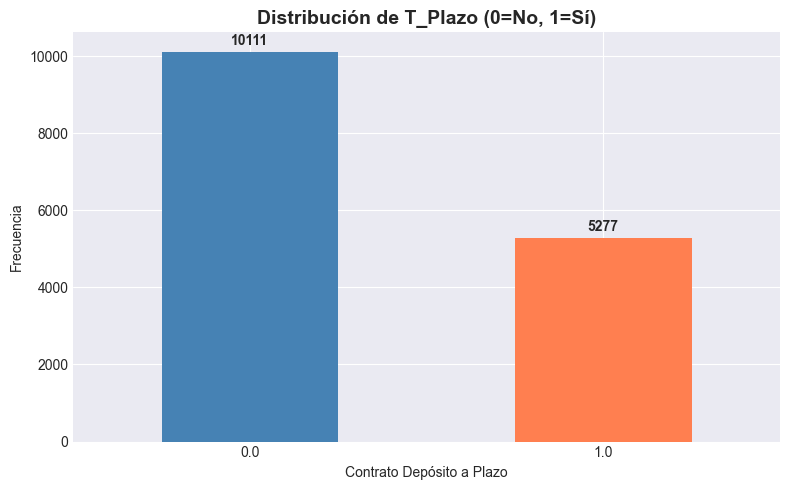


Distribución del target:
T_Plazo
0.0    10111
1.0     5277
Name: count, dtype: int64

Porcentajes:
T_Plazo
0.0    65.707044
1.0    34.292956
Name: proportion, dtype: float64


In [9]:
# Distribución de target
plt.figure(figsize=(8, 5))
df[target].value_counts().plot(kind="bar", color=['steelblue', 'coral'])
plt.title("Distribución de T_Plazo (0=No, 1=Sí)", fontsize=14, fontweight='bold')
plt.xlabel("Contrato Depósito a Plazo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
for i, v in enumerate(df[target].value_counts()):
    plt.text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDistribución del target:")
print(df[target].value_counts())
print(f"\nPorcentajes:")
print(df[target].value_counts(normalize=True) * 100)

#### Distribución de variables categóricas

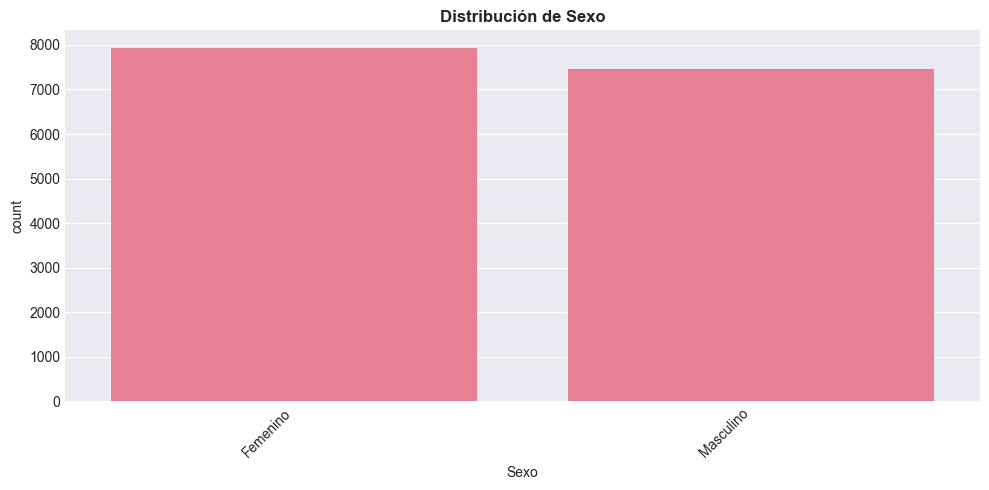

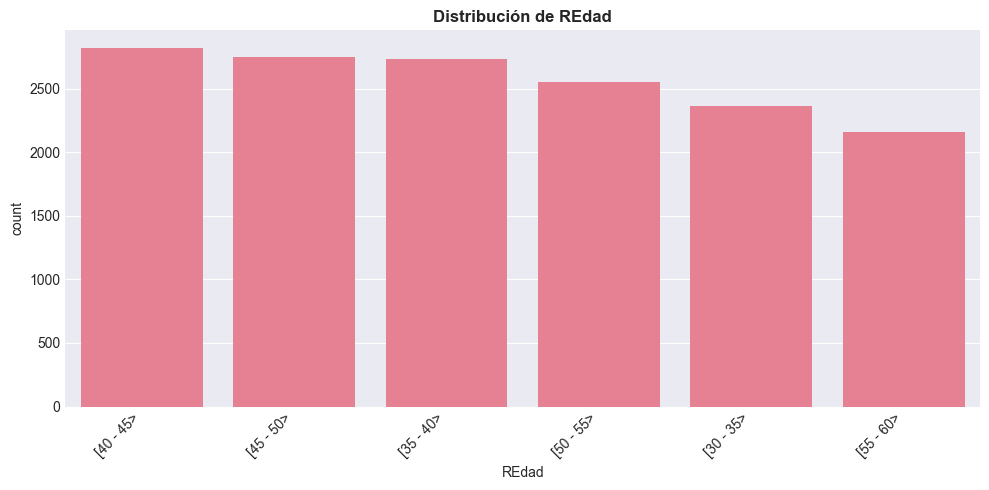

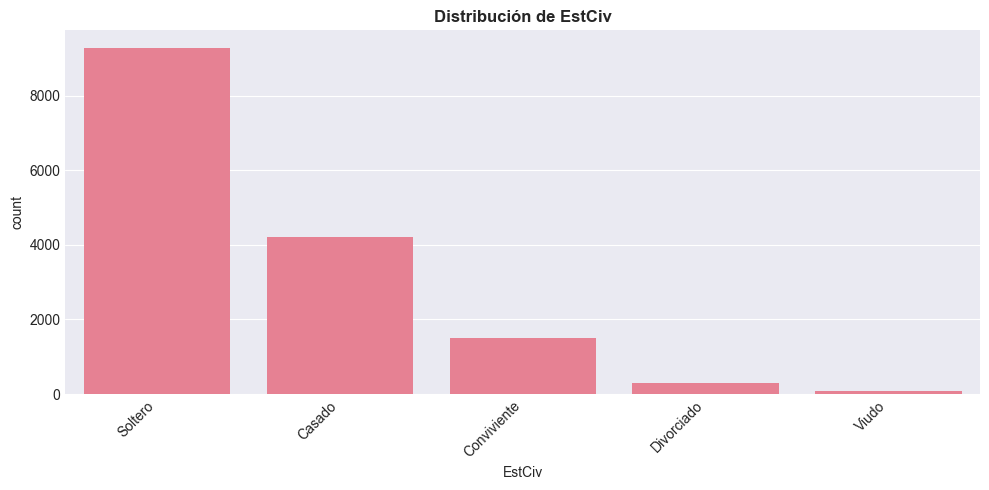

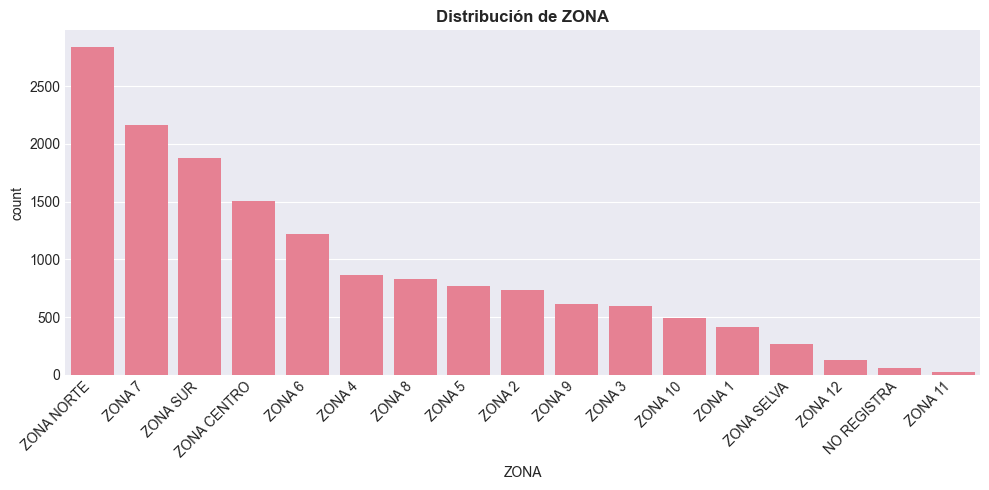

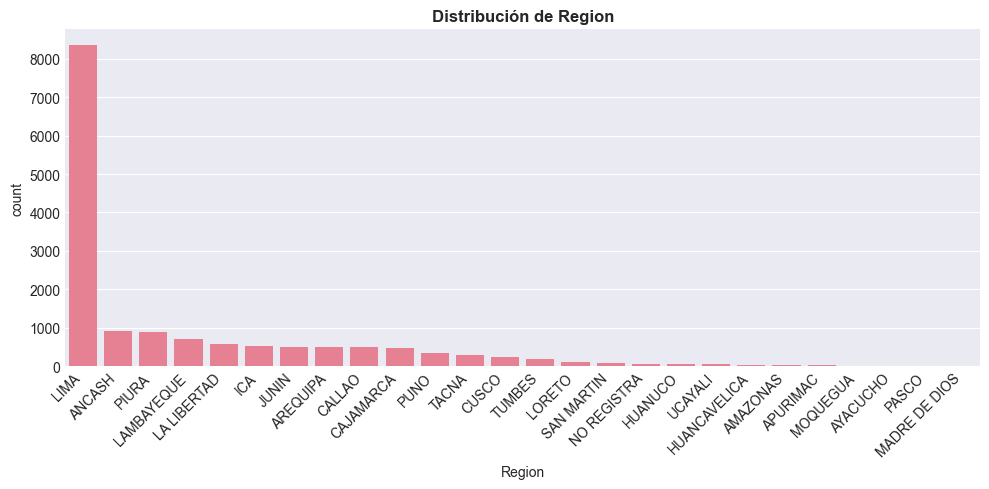

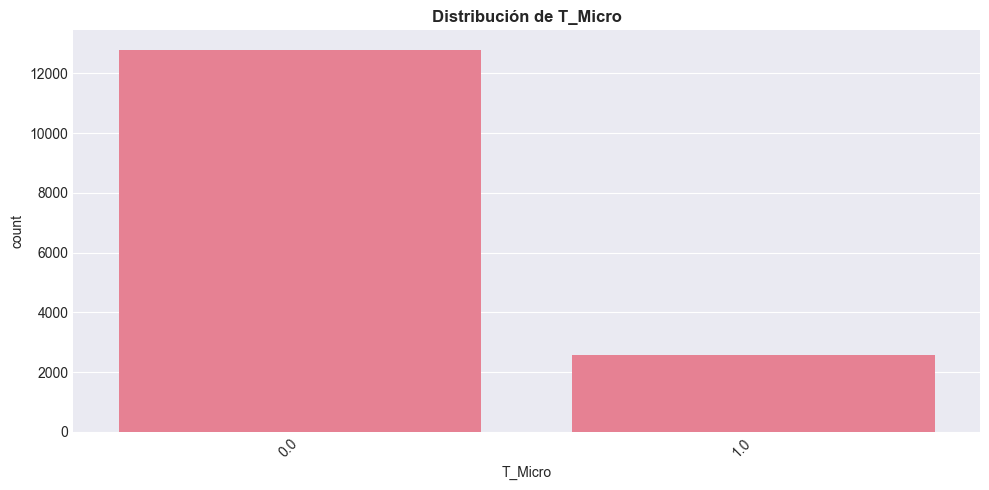

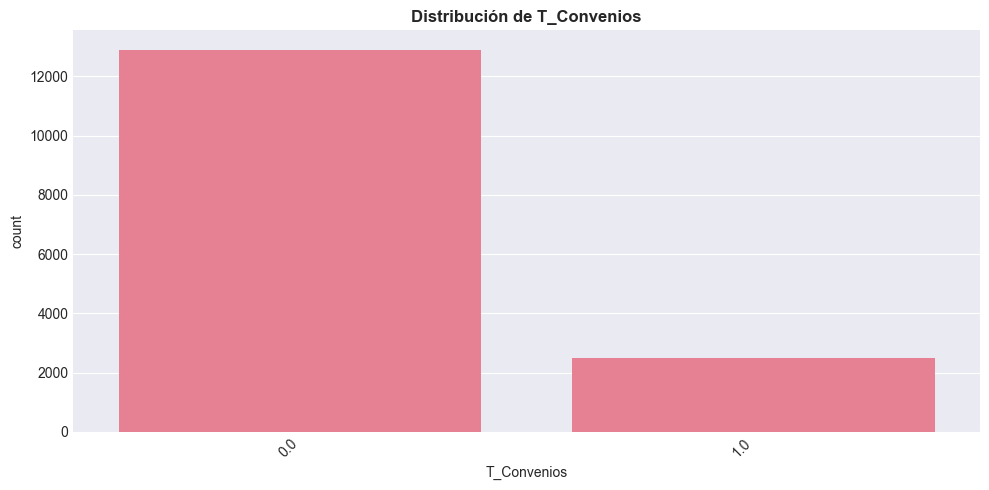

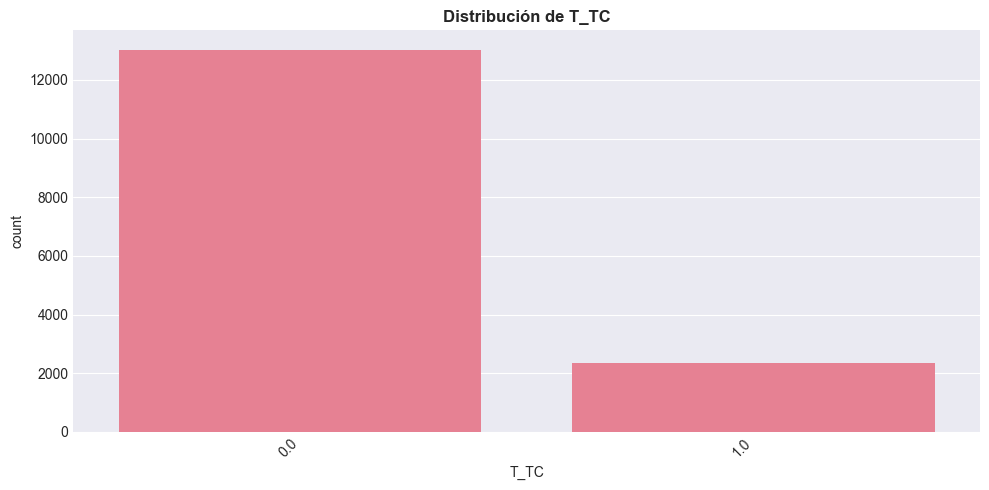

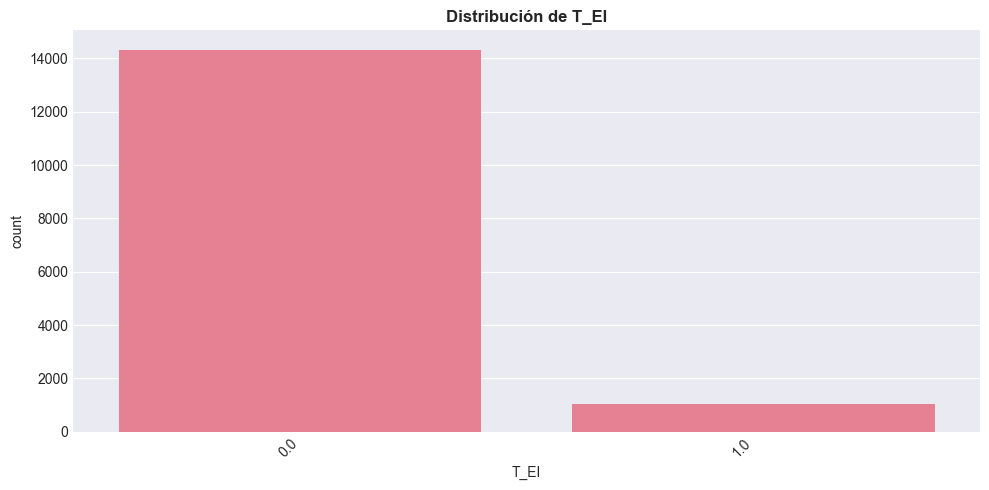

In [10]:
# Gráficos de distribuciones categóricas
for col in categoricas:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Distribución de {col}", fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

#### Distribución de variables numéricas

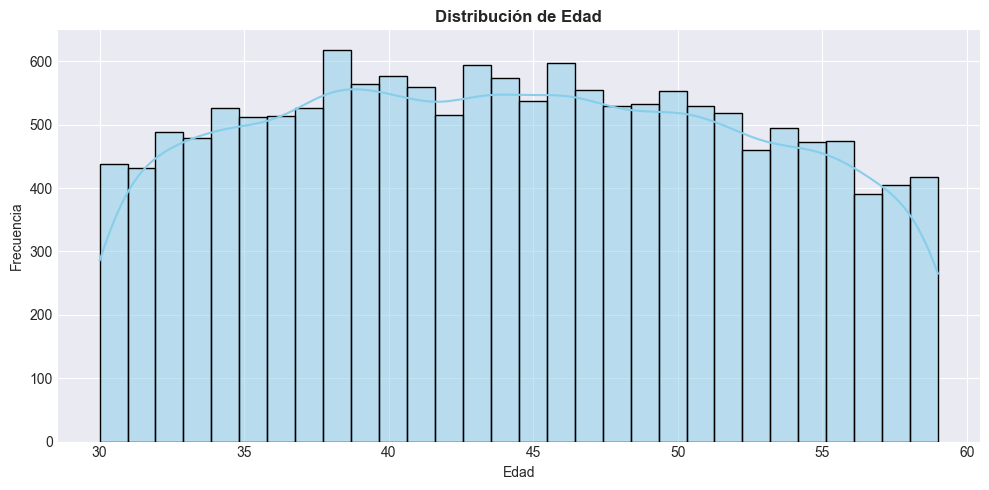

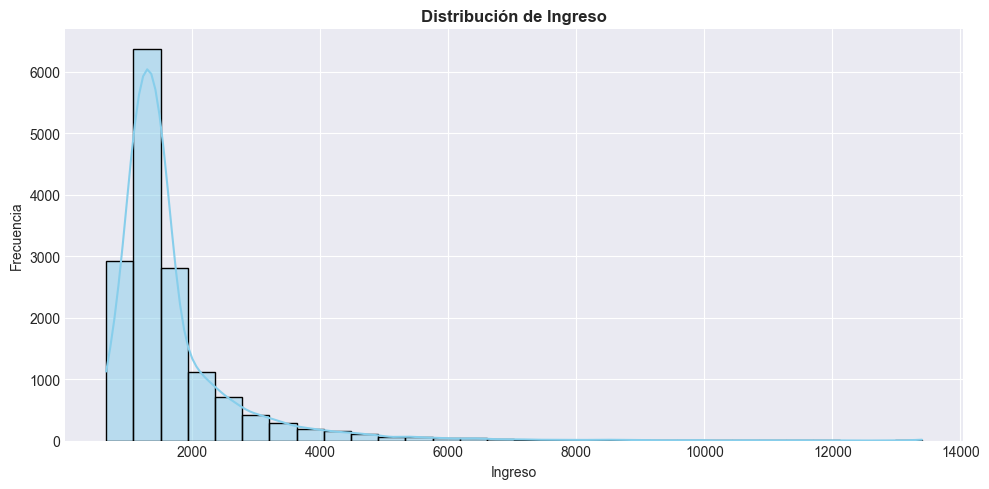

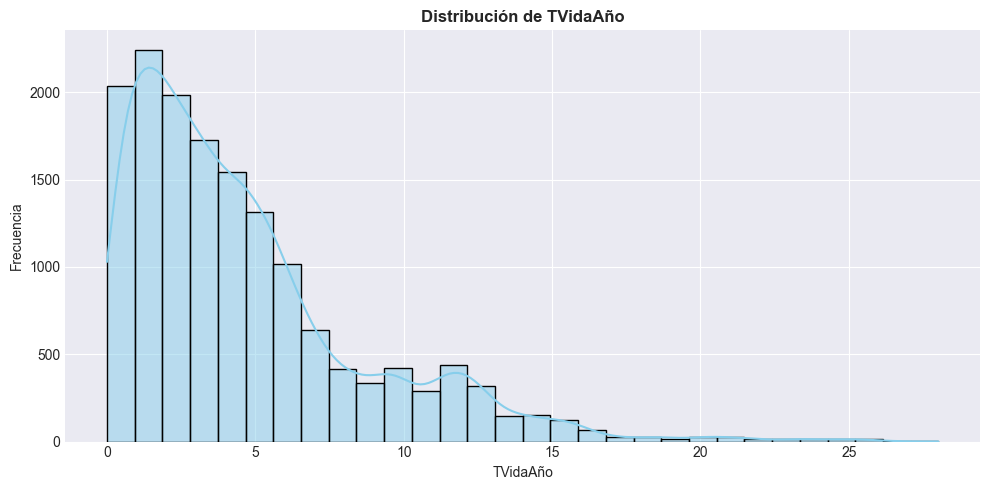

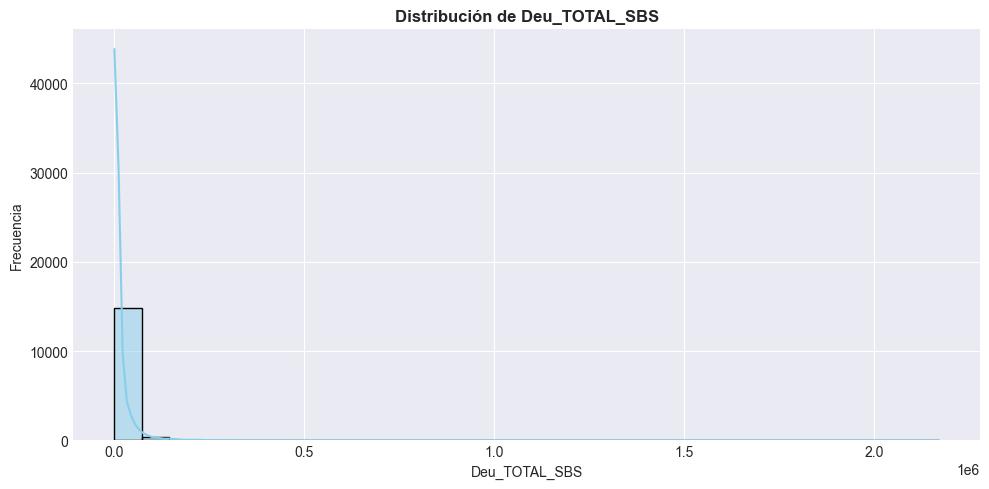

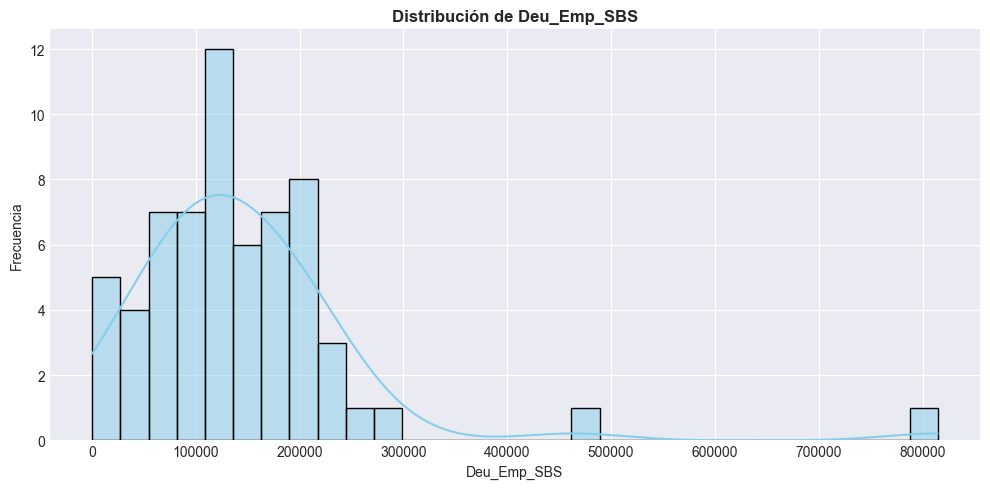

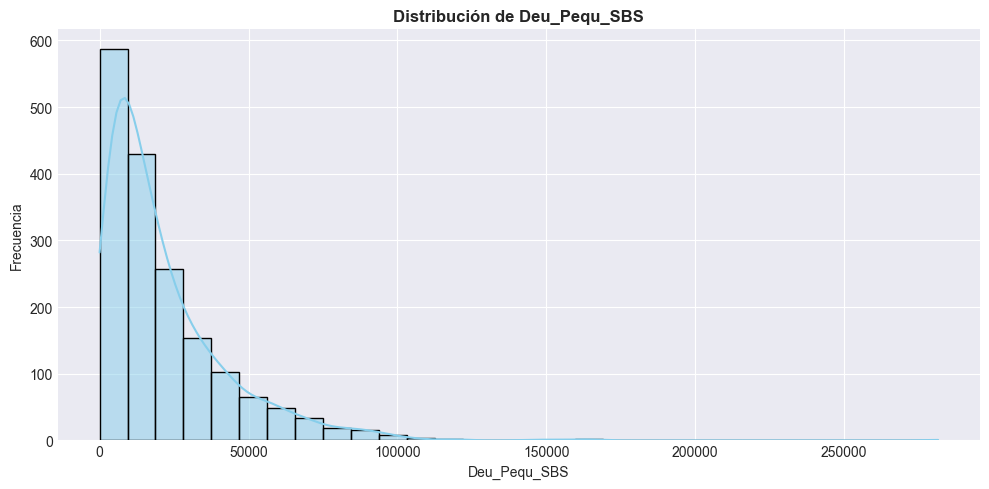

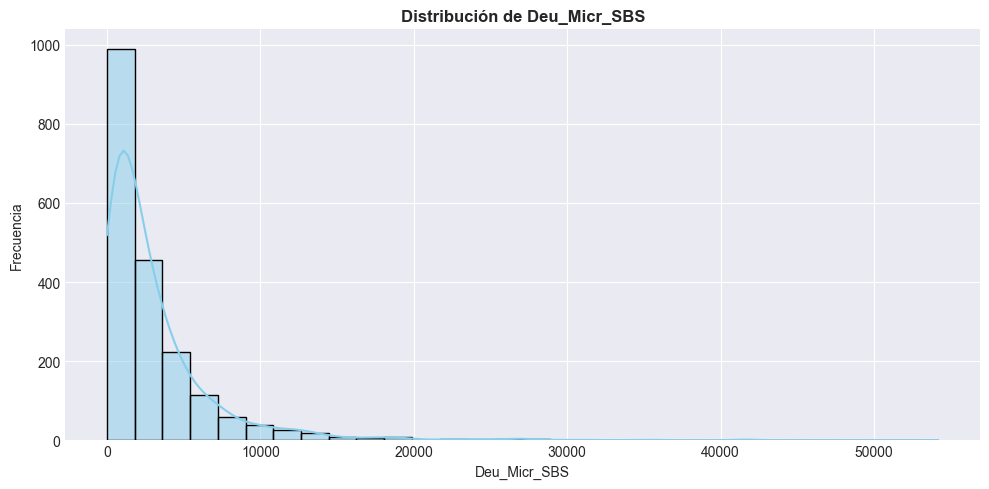

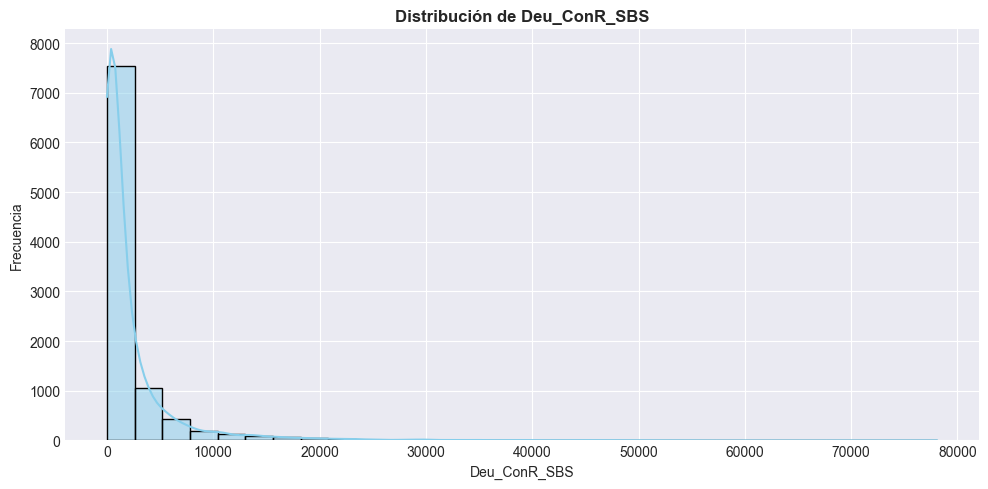

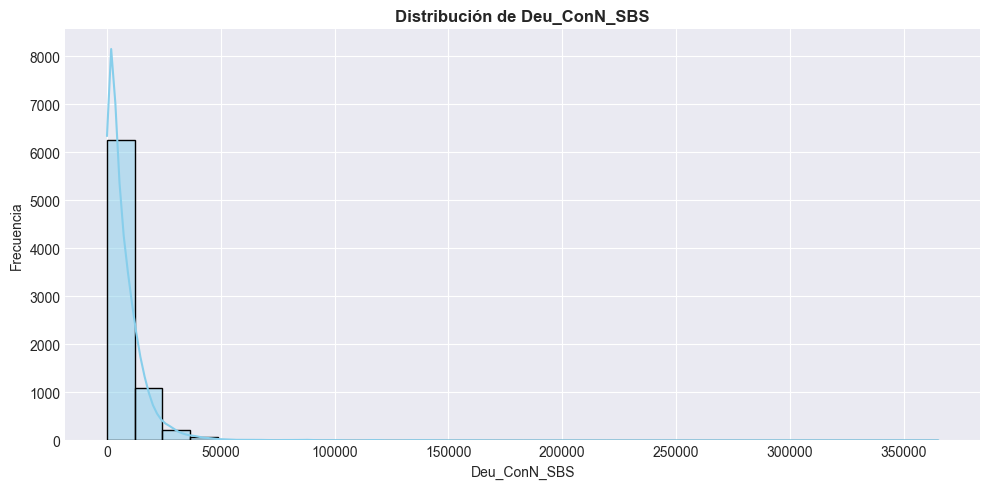

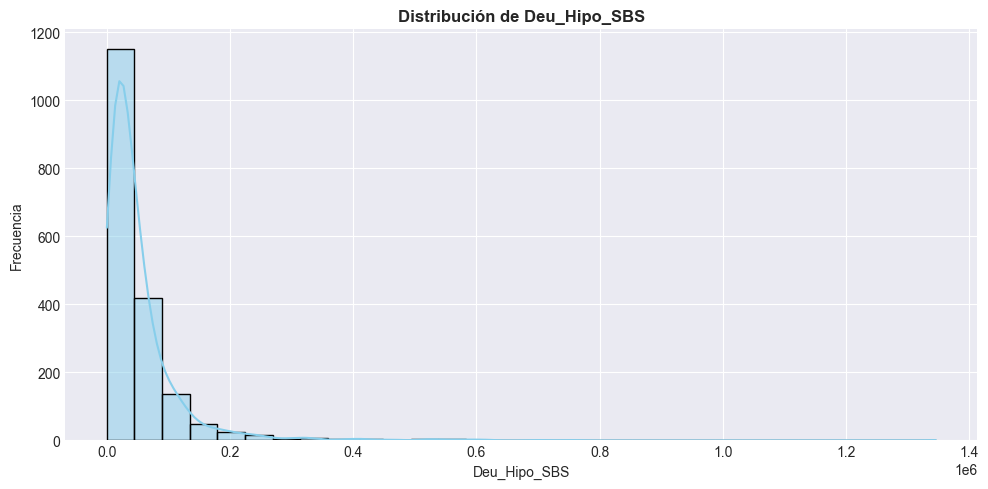

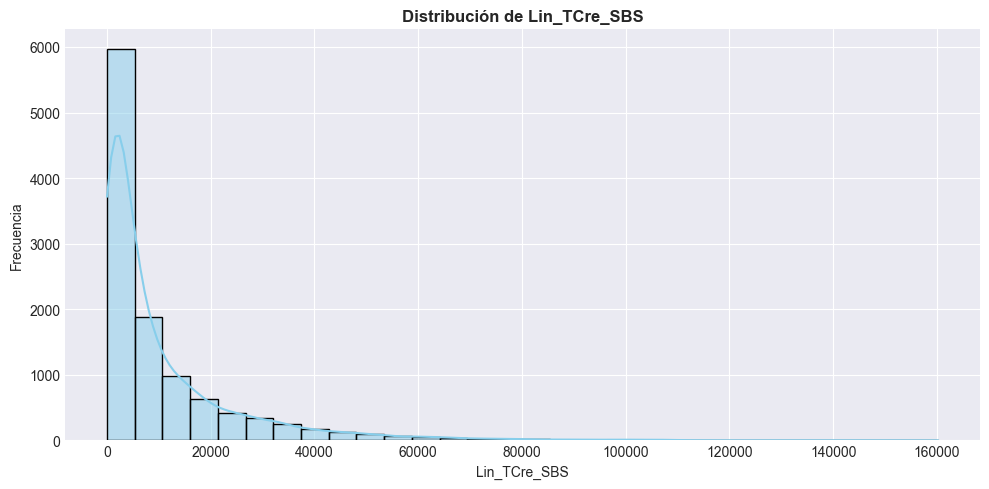

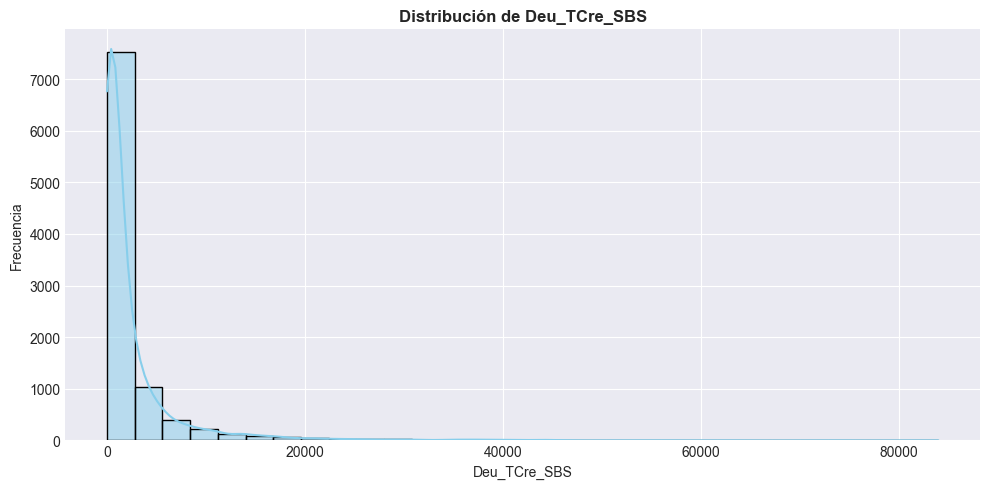

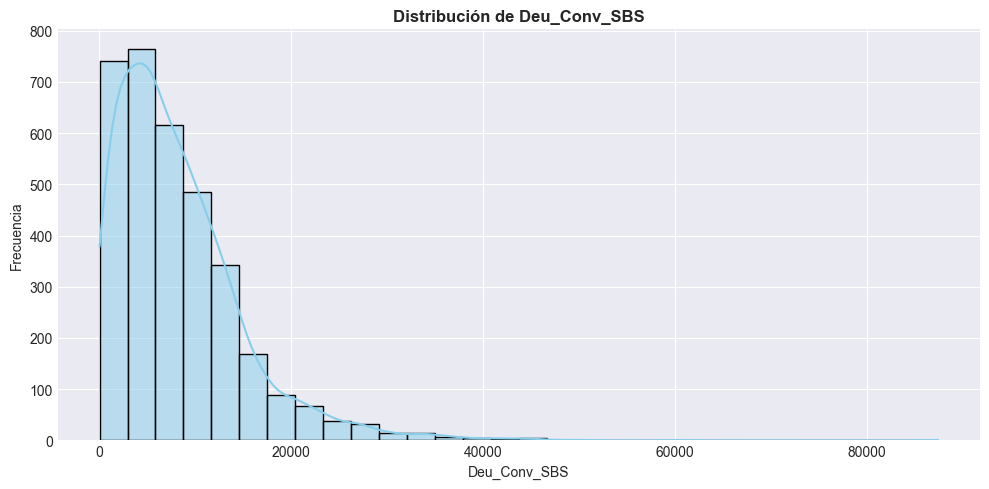

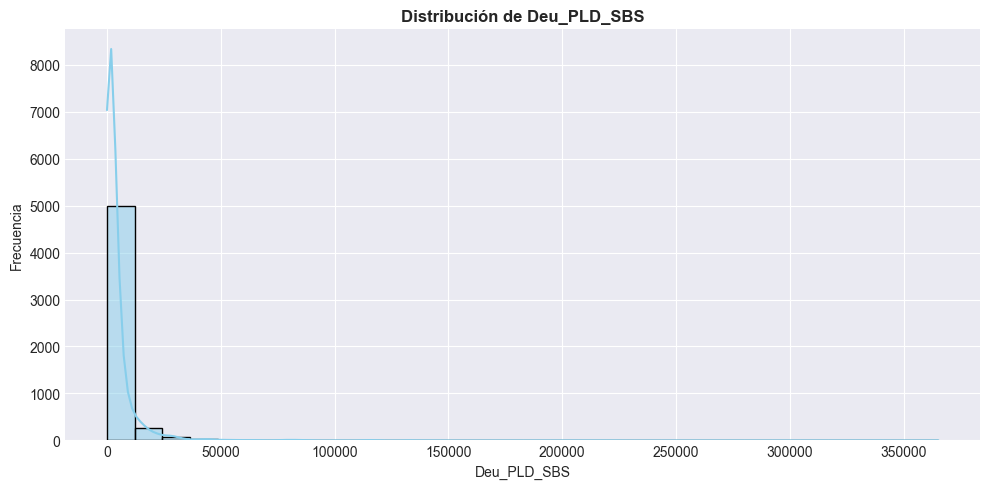

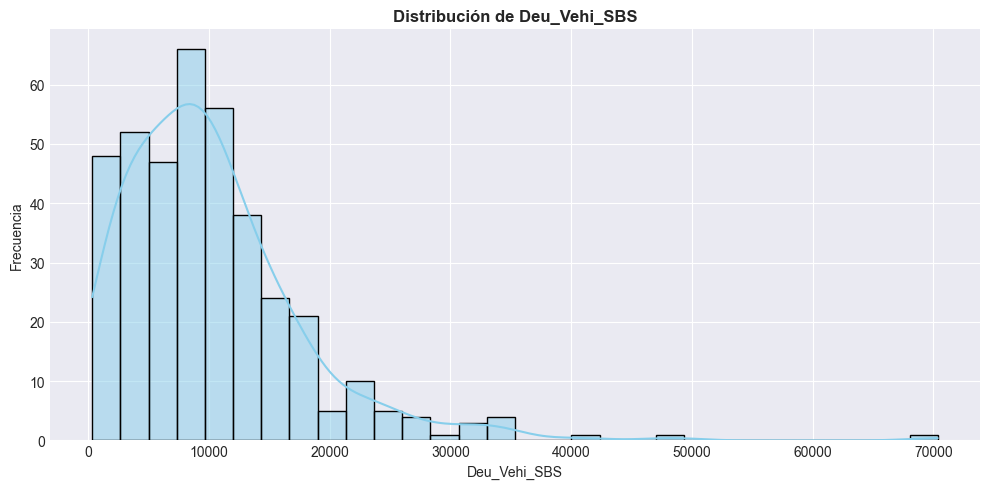

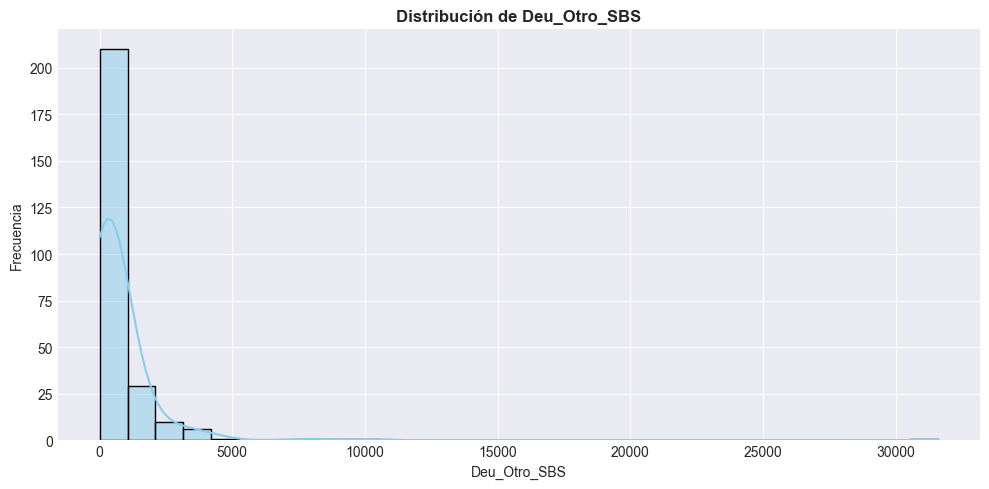

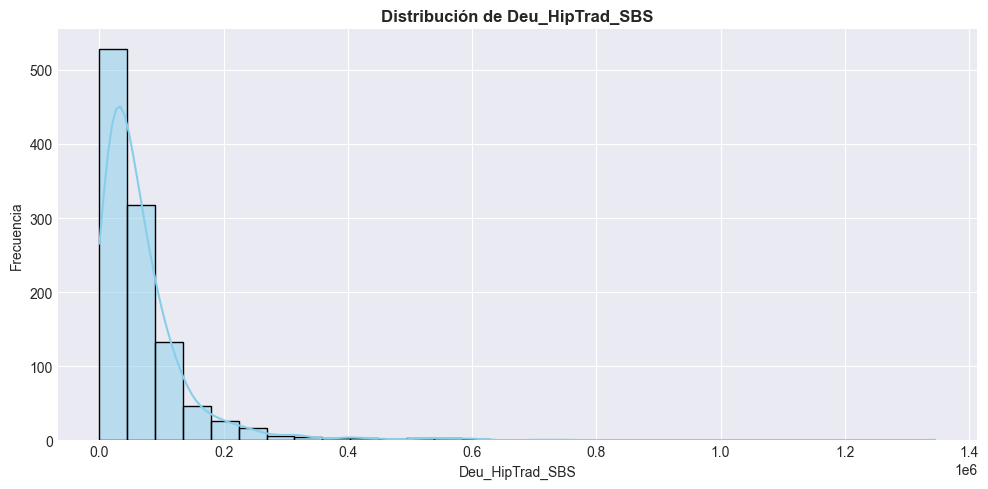

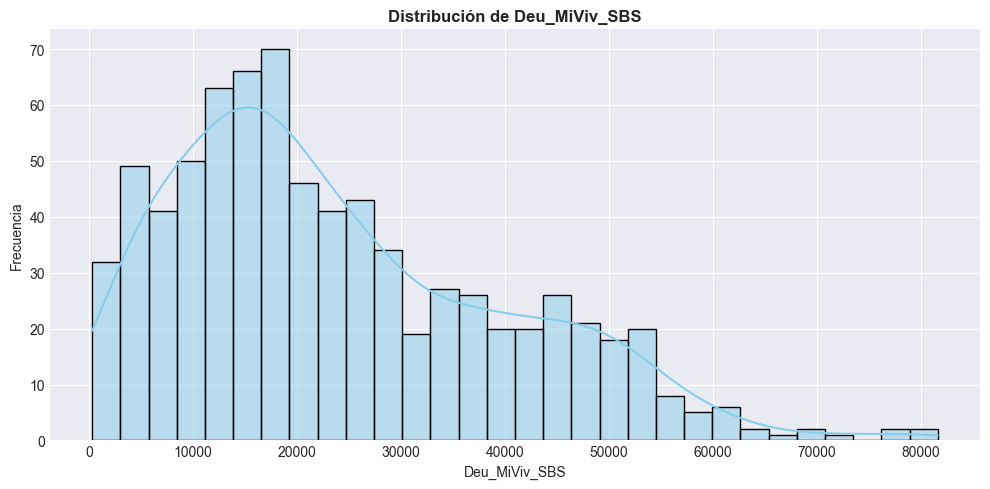

In [11]:
# Gráficos de distribuciones numéricas
for col in numericas:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(df[col], kde=True, bins=30, color='skyblue')
        plt.title(f"Distribución de {col}", fontsize=12, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

#### Análisis bivariado: Variables numéricas vs Target

In [12]:
# Análisis de variables numéricas vs target
cols_to_drop = [target, "CodCli", "CrossSell"] + [col for col in df.columns if col.startswith("T_") and col != target]
num_vars = df.select_dtypes(include=['int64', 'float64']).columns
num_vars = [col for col in num_vars if col not in cols_to_drop]

results_num = []
for col in num_vars:
    if col in df.columns:
        corr, pval = pointbiserialr(df[target], df[col])
        group0 = df[df[target] == 0][col]
        group1 = df[df[target] == 1][col]
        t_stat, p_val_ttest = ttest_ind(group0, group1, nan_policy='omit')
        results_num.append([col, corr, pval, t_stat, p_val_ttest])

df_results_num = pd.DataFrame(results_num,
                              columns=['Variable', 'Corr_pointbiserial', 'p_corr', 'T-stat', 'p_ttest'])

print("\nAnálisis de correlación Point-Biserial y T-test:")
df_results_num.sort_values('p_corr')


Análisis de correlación Point-Biserial y T-test:


,Variable,Corr_pointbiserial,p_corr,T-stat,p_ttest
1,TVidaAño,0.190923,2.926332e-126,-24.125904,2.926332e-126
3,Deu_TOTAL_SBS,-0.016125,4.547696e-02,2.000378,4.547696e-02
0,Edad,0.004911,5.424104e-01,-0.609186,5.424104e-01
2,Ingreso,NaN,NaN,-30.394579,4.133660e-197
4,Deu_Emp_SBS,NaN,NaN,-2.107087,3.922950e-02
5,Deu_Pequ_SBS,NaN,NaN,2.273063,2.314481e-02
6,Deu_Micr_SBS,NaN,NaN,3.877037,1.091907e-04
7,Deu_ConR_SBS,NaN,NaN,4.243119,2.224876e-05
8,Deu_ConN_SBS,NaN,NaN,-1.284748,1.989189e-01
9,Deu_Hipo_SBS,NaN,NaN,-4.648643,3.580873e-06


#### Visualización de distribuciones según Target

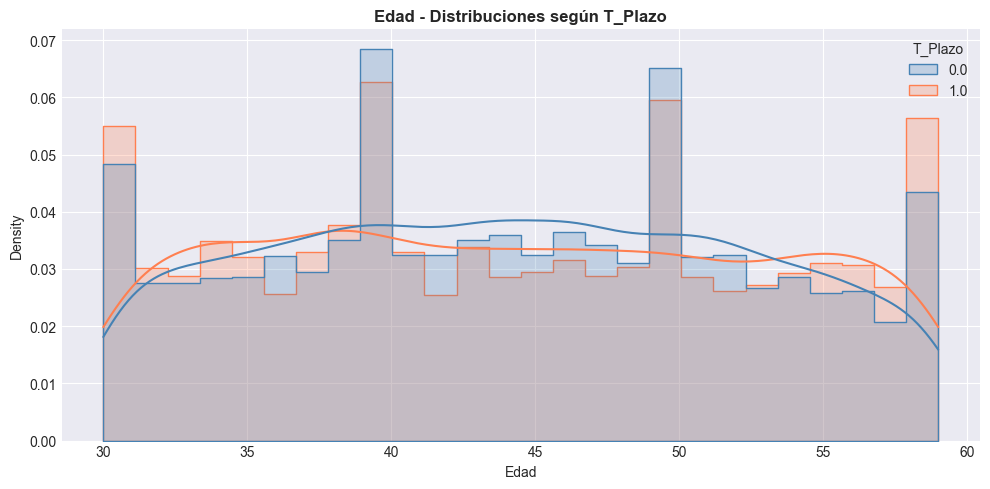

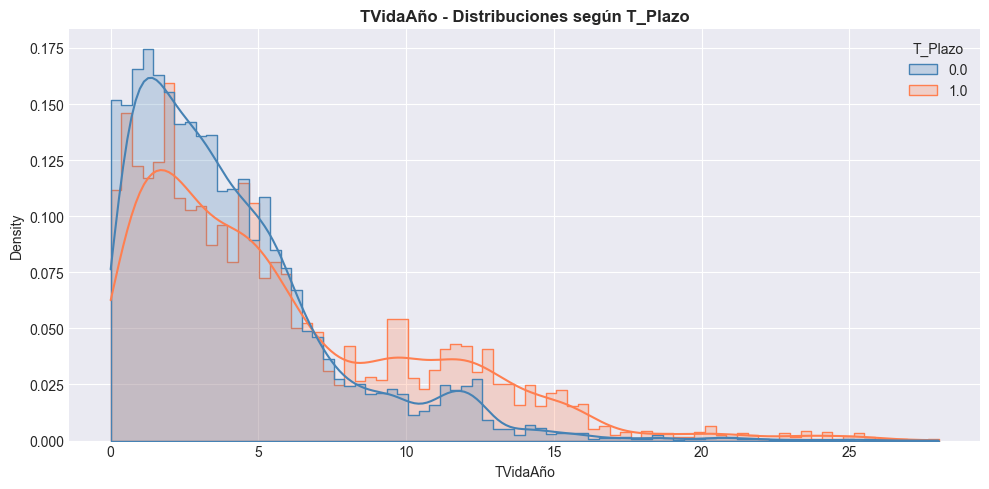

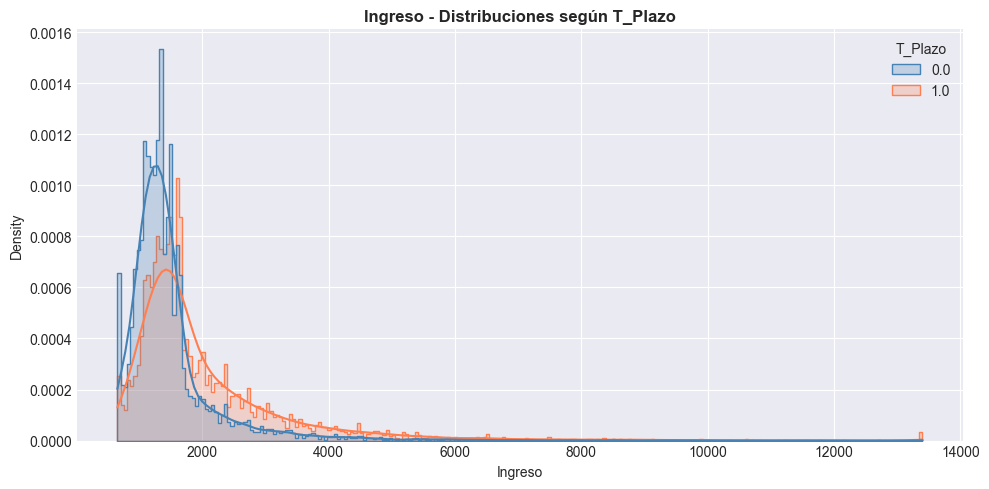

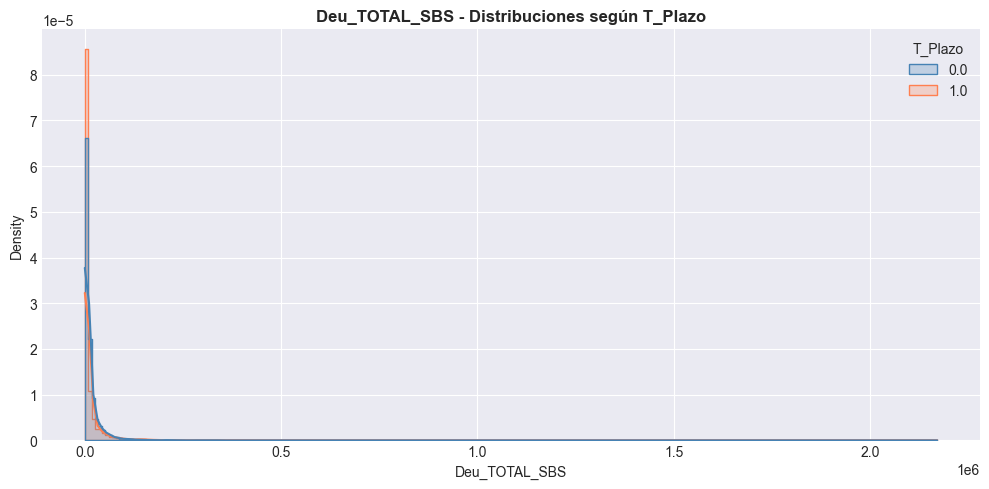

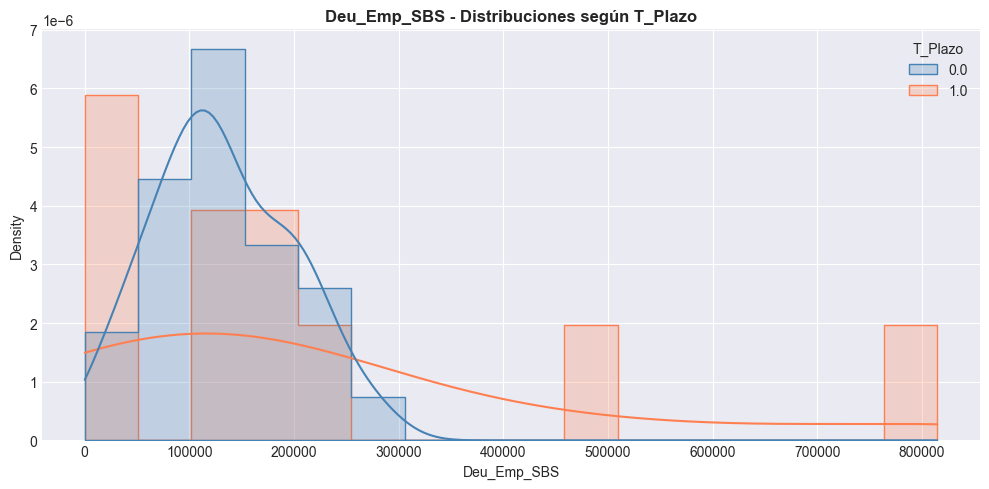

In [13]:
# Gráficos para variables numéricas según target
for col in num_vars[:5]:  # Primeras 5 para no saturar
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", 
                     stat="density", common_norm=False, palette=['steelblue', 'coral'])
        plt.title(f"{col} - Distribuciones según {target}", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

### 6.4 Pruebas de Hipótesis

Validamos las hipótesis formuladas en la sección 4.

In [14]:
# H1: Edad y T_Plazo (t-test)
edad_t1 = df[df[target] == 1]["Edad"]
edad_t0 = df[df[target] == 0]["Edad"]
t_stat, p_val = stats.ttest_ind(edad_t1, edad_t0, nan_policy="omit")
print("H1 - Edad vs T_Plazo:")
print(f"  p-value = {p_val:.4f}")
print(f"  Resultado: {'Significativa' if p_val < 0.05 else 'No significativa'}\n")

H1 - Edad vs T_Plazo:
  p-value = 0.5424
  Resultado: No significativa



In [15]:
# H2: Estado civil y T_Plazo (chi2)
if "EstCiv" in df.columns:
    tabla_civil = pd.crosstab(df["EstCiv"], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(tabla_civil)
    print("H2 - Estado Civil vs T_Plazo:")
    print(f"  p-value = {p:.4f}")
    print(f"  Resultado: {'Significativa' if p < 0.05 else 'No significativa'}\n")

H2 - Estado Civil vs T_Plazo:
  p-value = 0.0000
  Resultado: Significativa



In [16]:
# H3: Ingresos y T_Plazo (t-test)
ingresos_t1 = df[df[target] == 1]["Ingreso"]
ingresos_t0 = df[df[target] == 0]["Ingreso"]
t_stat, p_val = stats.ttest_ind(ingresos_t1, ingresos_t0, nan_policy="omit")
print("H3 - Ingresos vs T_Plazo:")
print(f"  p-value = {p_val:.4f}")
print(f"  Resultado: {'Significativa' if p_val < 0.05 else 'No significativa'}\n")

H3 - Ingresos vs T_Plazo:
  p-value = 0.0000
  Resultado: Significativa



In [20]:
# H4: Producto vigente (Tarjeta de crédito) y T_Plazo (chi2)
if "T_TC" in df.columns:
    tabla_credito = pd.crosstab(df["T_TC"], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(tabla_credito)
    print("H4 - Tenencia de Tarjeta de Crédito vs T_Plazo:")
    print(f"  p-value = {p:.4f}")
    print(f"  Resultado: {'Significativa' if p < 0.05 else 'No significativa'}\n")

H4 - Tenencia de Tarjeta de Crédito vs T_Plazo:
  p-value = 0.0000
  Resultado: Significativa



### Resumen de Hipótesis

**H1 – Edad:** Generalmente no significativa → la edad no influye fuertemente en la contratación de DP.

**H2 – Estado Civil:** Muy significativa → el estado civil influye en la propensión.

**H3 – Ingresos:** Muy significativa → mayores ingresos aumentan la probabilidad de contratar DP.

**H4 – Crédito:** Muy significativa → tener productos de crédito vigentes está asociado a mayor propensión (cross-selling).

## 7. Conclusiones del EDA

1. **Variables clave identificadas:** Estado civil, ingresos y tenencia de productos de crédito son predictores importantes.
2. **Edad** no resultó significativa como predictor único.
3. **Distribuciones:** Se observan diferencias claras entre clientes que contratan y no contratan DP.
4. **Siguiente paso:** Entrenamiento de modelos automatizado está disponible en `src/train.py`.

---

### Para ejecutar el pipeline completo:

```bash
# 1. Preparar datos (raw → silver)
python src/data_preparation.py

# 2. Entrenar modelos
python src/train.py
```